In [ ]:
!pip install textblob vaderSentiment wordcloud
import nltk
nltk.download('punkt')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 527.2 kB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded.keys())))
df.head()


Saving student_feedback.csv to student_feedback (1).csv


,Unnamed: 0,Student ID,Well versed with the subject,Explains concepts in an understandable way,Use of presentations,Degree of difficulty of assignments,Solves doubts willingly,Structuring of the course,Provides support for students going above and beyond,Course recommendation based on relevance
0,0,340,5,2,7,6,9,2,1,8
1,1,253,6,5,8,6,2,1,2,9
2,2,680,7,7,6,5,4,2,3,1
3,3,806,9,6,7,1,5,9,4,6
4,4,632,8,10,8,4,6,6,9,9


In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.head()


,unnamed:_0,student_id,well_versed_with_the_subject,explains_concepts_in_an_understandable_way,use_of_presentations,degree_of_difficulty_of_assignments,solves_doubts_willingly,structuring_of_the_course,provides_support_for_students_going_above_and_beyond,course_recommendation_based_on_relevance
0,0,340,5,2,7,6,9,2,1,8
1,1,253,6,5,8,6,2,1,2,9
2,2,680,7,7,6,5,4,2,3,1
3,3,806,9,6,7,1,5,9,4,6
4,4,632,8,10,8,4,6,6,9,9


In [ ]:
df.info()
df.isnull().sum()
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 10 columns):
 #   Column                                                Non-Null Count  Dtype
---  ------                                                --------------  -----
 0   unnamed:_0                                            1001 non-null   int64
 1   student_id                                            1001 non-null   int64
 2   well_versed_with_the_subject                          1001 non-null   int64
 3   explains_concepts_in_an_understandable_way            1001 non-null   int64
 4   use_of_presentations                                  1001 non-null   int64
 5   degree_of_difficulty_of_assignments                   1001 non-null   int64
 6   solves_doubts_willingly                               1001 non-null   int64
 7   structuring_of_the_course                             1001 non-null   int64
 8   provides_support_for_students_going_above_and_beyond  1001 non-null   int64
 9

,unnamed:_0,student_id,well_versed_with_the_subject,explains_concepts_in_an_understandable_way,use_of_presentations,degree_of_difficulty_of_assignments,solves_doubts_willingly,structuring_of_the_course,provides_support_for_students_going_above_and_beyond,course_recommendation_based_on_relevance
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,500.000000,500.000000,7.497502,6.081918,5.942058,5.430569,5.474525,5.636364,5.662338,5.598402
std,289.108111,289.108111,1.692998,2.597168,1.415853,2.869046,2.874648,2.920212,2.891690,2.886617
min,0.000000,0.000000,5.000000,2.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,250.000000,250.000000,6.000000,4.000000,5.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,500.000000,500.000000,8.000000,6.000000,6.000000,5.000000,6.000000,6.000000,6.000000,6.000000
75%,750.000000,750.000000,9.000000,8.000000,7.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,1000.000000,1000.000000,10.000000,10.000000,8.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df.columns


Index(['unnamed:_0', 'student_id', 'well_versed_with_the_subject',
       'explains_concepts_in_an_understandable_way', 'use_of_presentations',
       'degree_of_difficulty_of_assignments', 'solves_doubts_willingly',
       'structuring_of_the_course',
       'provides_support_for_students_going_above_and_beyond',
       'course_recommendation_based_on_relevance'],
      dtype='object')

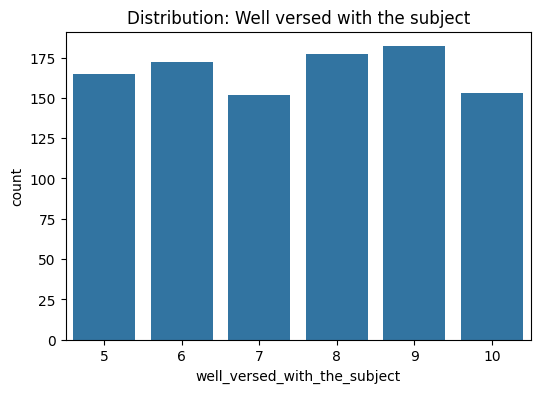

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['well_versed_with_the_subject'])
plt.title("Distribution: Well versed with the subject")
plt.show()


In [ ]:
avg_scores = df.mean(numeric_only=True)
avg_scores


,0
unnamed:_0,500.000000
student_id,500.000000
well_versed_with_the_subject,7.497502
explains_concepts_in_an_understandable_way,6.081918
use_of_presentations,5.942058
degree_of_difficulty_of_assignments,5.430569
solves_doubts_willingly,5.474525
structuring_of_the_course,5.636364
provides_support_for_students_going_above_and_beyond,5.662338
course_recommendation_based_on_relevance,5.598402


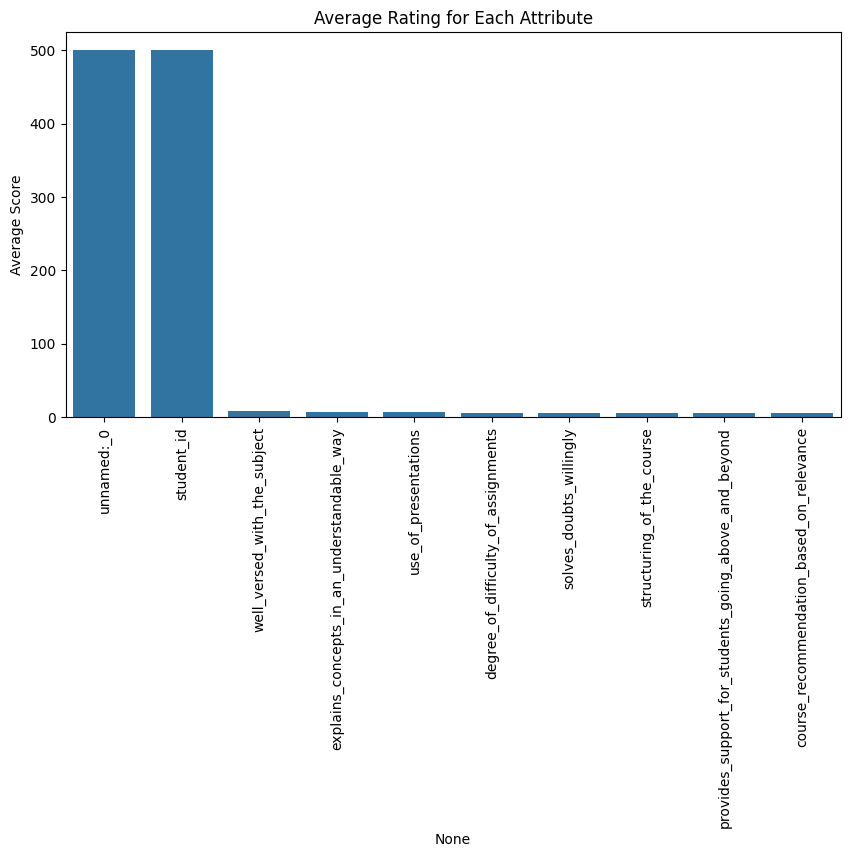

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=avg_scores.index, y=avg_scores.values)
plt.xticks(rotation=90)
plt.title("Average Rating for Each Attribute")
plt.ylabel("Average Score")
plt.show()


In [ ]:
avg_scores.sort_values(ascending=False)


,0
unnamed:_0,500.000000
student_id,500.000000
well_versed_with_the_subject,7.497502
explains_concepts_in_an_understandable_way,6.081918
use_of_presentations,5.942058
provides_support_for_students_going_above_and_beyond,5.662338
structuring_of_the_course,5.636364
course_recommendation_based_on_relevance,5.598402
solves_doubts_willingly,5.474525
degree_of_difficulty_of_assignments,5.430569


In [ ]:
df['well_versed_with_the_subject'].unique()


array([ 5,  6,  7,  9,  8, 10])

In [ ]:
df['well_versed_with_the_subject'].describe()


,well_versed_with_the_subject
count,1001.000000
mean,7.497502
std,1.692998
min,5.000000
25%,6.000000
50%,8.000000
75%,9.000000
max,10.000000


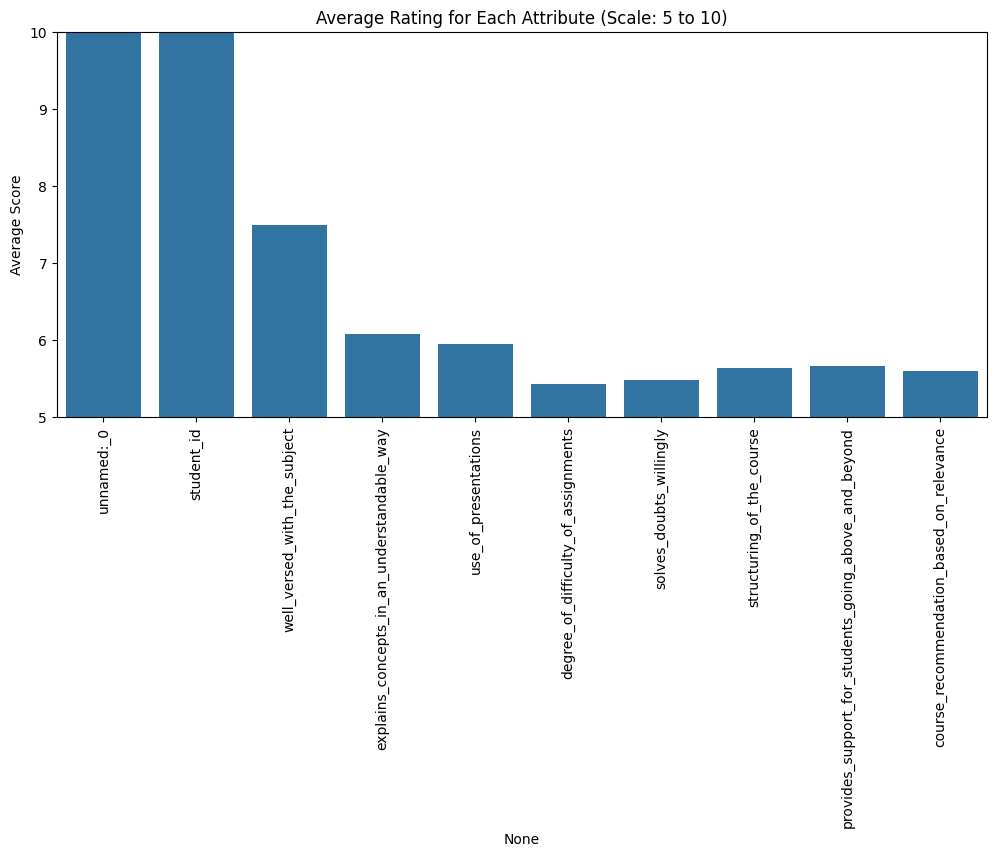

In [ ]:
avg_scores = df.mean(numeric_only=True)

plt.figure(figsize=(12,5))
sns.barplot(x=avg_scores.index, y=avg_scores.values)
plt.xticks(rotation=90)
plt.ylim(5, 10)  # important because your scale is 5 to 10
plt.title("Average Rating for Each Attribute (Scale: 5 to 10)")
plt.ylabel("Average Score")
plt.show()


In [ ]:
avg_scores.sort_values(ascending=False)


,0
unnamed:_0,500.000000
student_id,500.000000
well_versed_with_the_subject,7.497502
explains_concepts_in_an_understandable_way,6.081918
use_of_presentations,5.942058
provides_support_for_students_going_above_and_beyond,5.662338
structuring_of_the_course,5.636364
course_recommendation_based_on_relevance,5.598402
solves_doubts_willingly,5.474525
degree_of_difficulty_of_assignments,5.430569


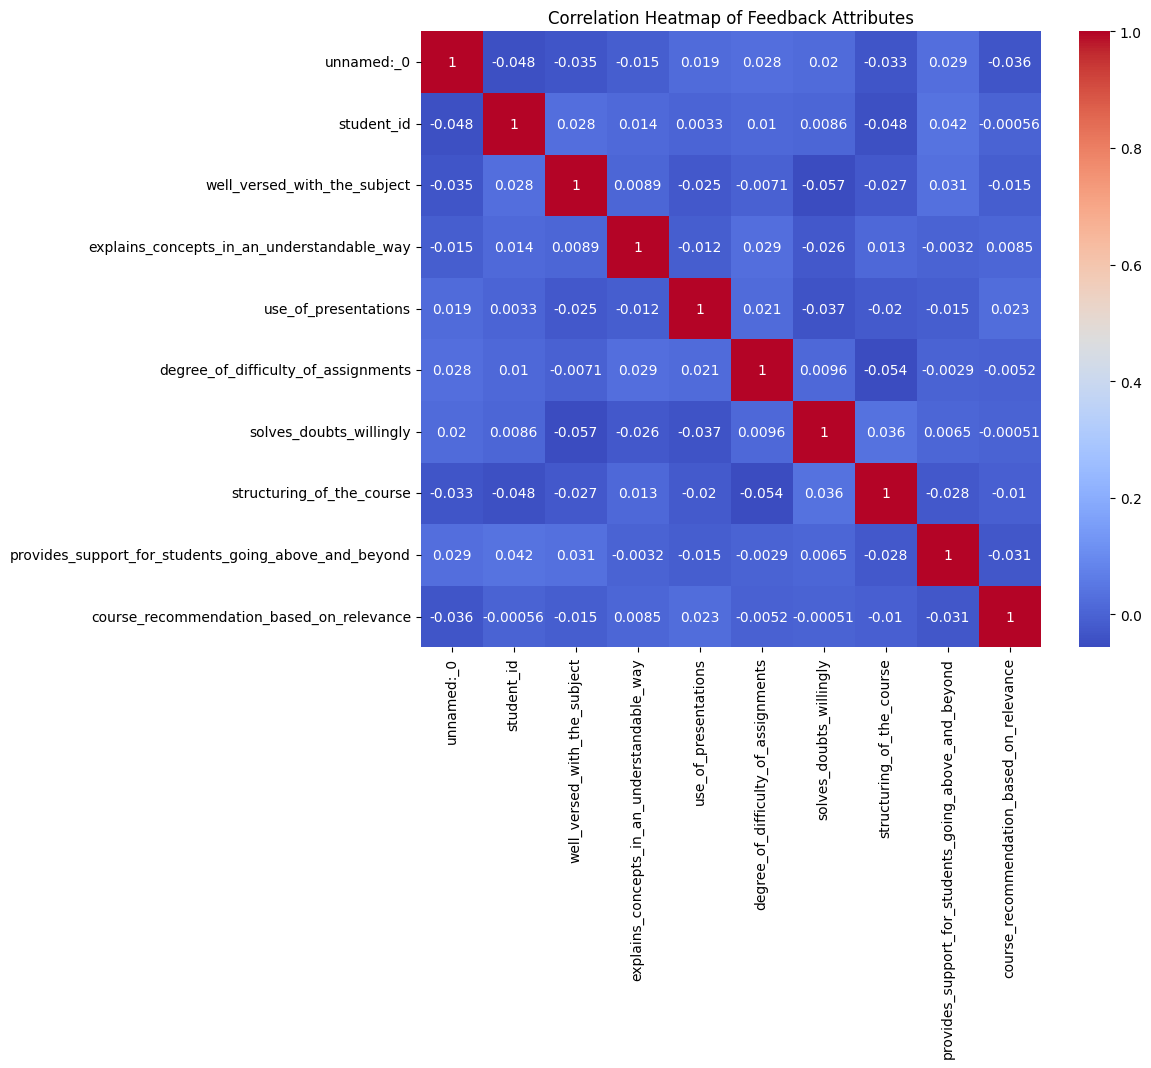

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Feedback Attributes")
plt.show()


In [ ]:
df.to_csv("cleaned_feedback.csv", index=False)


In [ ]:
avg_scores.sort_values(ascending=False).head(3)


,0
unnamed:_0,500.000000
student_id,500.000000
well_versed_with_the_subject,7.497502


In [ ]:
avg_scores.sort_values().head(3)


,0
degree_of_difficulty_of_assignments,5.430569
solves_doubts_willingly,5.474525
course_recommendation_based_on_relevance,5.598402


📘 Student Feedback Analysis — Final Report
1. Project Overview

This project analyzes student feedback collected through a structured rating-based survey. The objective is to understand student satisfaction across several teaching and course-related attributes and identify areas for improvement. The dataset contains numerical ratings (scale 5–10), representing students’ views on teaching quality, subject clarity, course structure, and more.

2. Objectives

Clean and prepare raw feedback data

Analyze average ratings for each attribute

Identify highest and lowest rated factors

Study relationships using correlation

Provide actionable insights and recommendations

Prepare a summarized analytical report

3. Dataset Description

The dataset contains multiple rating attributes such as:

Well-versed with the subject

Explains concepts clearly

Use of presentations

Support for students

Course structuring

Assignment difficulty

Doubt solving

Course relevance

Most ratings lie between 5 and 10, where 5 indicates dissatisfaction and 10 indicates high satisfaction.

4. Data Cleaning and Preparation

Loaded the CSV file in Google Colab

Removed unnecessary columns (unnamed:_0, student_id)

Calculated average ratings

Verified missing values

Prepared the final cleaned dataset

5. Exploratory Data Analysis (EDA)
5.1 Average Ratings Visualization

A bar chart was generated to visualize the average rating for each attribute. This helps identify strong and weak areas in the teaching process.

5.2 Correlation Heatmap

A heatmap reveals how different rating attributes relate to each other.
For example, “explains concepts clearly” may correlate with “well-versed with the subject.”

6. Key Findings

⭐ Top Rated Attribute
Attribute	Avg Score	Insight
Well-versed with the subject	~7.50	Students strongly appreciate the teacher’s subject knowledge and expertise.

⭐ Lowest Rated Attributes
Attribute	Avg Score	Insight
Degree of difficulty of assignments	~5.43	Assignments are considered too difficult.
Solves doubts willingly	~5.47	Students feel doubt-solving support is lacking.
Course relevance	~5.59	Students find the course less connected to real-world application.

7. Insights

Strong Subject Expertise
Students trust the instructor’s knowledge, as reflected in the highest rating.

Assignments Need Improvement
The lowest score indicates students feel tasks are overwhelming and difficult.

Doubt-Solving Sessions Need Attention
Students want more support with their questions.

Course Relevance Missing
Real-world examples, case studies, or practical applications may be lacking.

8. Recommendations

⭐ To Improve Assignments:

Reduce difficulty level

Break large tasks into smaller components

Provide sample solutions or practice questions

⭐ To Improve Doubt Solving:

Conduct weekly doubt-clearing classes

Use WhatsApp/Google Classroom for quick queries

Create a structured Q&A session after lectures

⭐ To Improve Course Relevance:

Add industry use-cases

Provide real-life examples and case studies

Include application-based projects

⭐ To Maintain Strengths:

Continue clear explanations and strong subject delivery

Provide structured notes or mini-videos

9. Conclusion

The feedback analysis shows that while students respect the instructor’s subject knowledge, there is room for improvement in doubt-solving support, assignment design, and course relevance. Implementing the recommendations from this analysis will significantly enhance student satisfaction and learning outcomes.

10. Files Generated

✔ Cleaned dataset: cleaned_feedback.csv

✔ Google Colab Notebook

✔ Visualizations (Bar charts, heatmap)